# Microsoft Fara1.5-4BをColabで動かす

Microsoftの **Fara1.5-4B** を4bit量子化で読み込み、ブラウザ画面のスクリーンショットから「次に行うべき操作」を推定します。

書籍のPhi-4 Notebookとできるだけ同じ構成にしています。

> **実行方針**  
> Gradioは無条件にアップグレードせず、Colabに入っている版を使用します。  
> このNotebookでは実ブラウザを自動操作せず、スクリーンショットに対する次アクション予測だけを行います。


In [1]:
# =========================================
# コード1 実行環境の準備
# =========================================
!nvidia-smi -L || echo "No GPU"
!python -V

# TorchとGradioはColab既定版を利用する。
# Fara1.5はTransformers 5.2以降を要求する。
%pip -q install -U "transformers>=5.2,<6" accelerate bitsandbytes

import torch
import transformers

if not torch.cuda.is_available():
    raise RuntimeError("GPUランタイムを有効にしてください。")

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("GPU:", torch.cuda.get_device_name(0))


GPU 0: NVIDIA RTX PRO 6000 Blackwell Server Edition (UUID: GPU-9a24f1fa-317b-0640-b521-214c3a66c2d9)
Python 3.12.13
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 238.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 78.0 MB/s eta 0:00:00
PyTorch: 2.11.0+cu128
Transformers: 5.15.0
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [2]:
# =========================================
# コード2 Google Driveとキャッシュ設定
# =========================================
from google.colab import drive

drive.mount("/content/drive")

import os
import shutil
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/LocalLLM")
USE_DRIVE_CACHE = True
DISABLE_XET = False
OFFLINE_MODE = False

if USE_DRIVE_CACHE:
    CACHE_DIR = PROJECT_DIR / "Program" / "hf_cache_fara15_4b"
else:
    CACHE_DIR = Path("/content/hf_cache_fara15_4b")

CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ["HF_HUB_CACHE"] = str(CACHE_DIR)

if DISABLE_XET:
    os.environ["HF_HUB_DISABLE_XET"] = "1"

if OFFLINE_MODE:
    os.environ["HF_HUB_OFFLINE"] = "1"

usage = shutil.disk_usage(CACHE_DIR)
print("CACHE_DIR:", CACHE_DIR)
print(f"free space: {usage.free / 1024**3:.1f} GB")

if USE_DRIVE_CACHE and usage.free < 15 * 1024**3:
    print("WARNING: Fara1.5-4B用に15GB程度の空き容量を推奨します。")


Mounted at /content/drive
CACHE_DIR: /content/drive/MyDrive/Colab Notebooks/LocalLLM/Program/hf_cache_fara15_4b
free space: 178.9 GB


In [3]:
# =========================================
# コード3 Fara1.5-4Bモデルと応答生成関数
# =========================================
import re
import torch
from transformers import (
    AutoModelForMultimodalLM,
    AutoProcessor,
    BitsAndBytesConfig,
)

MODEL_ID = "microsoft/Fara1.5-4B"

COMPUTE_DTYPE = (
    torch.bfloat16
    if torch.cuda.is_bf16_supported()
    else torch.float16
)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    cache_dir=str(CACHE_DIR),
)

model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    cache_dir=str(CACHE_DIR),
    low_cpu_mem_usage=True,
)

model.eval()

try:
    INPUT_DEVICE = model.device
except Exception:
    INPUT_DEVICE = next(model.parameters()).device


# Microsoft公式ではFara CLI / MagenticLiteの完全なsystem promptと
# computer_use schemaを推奨している。
# このNotebookではモデル単体の挙動確認に限定し、
# 最小限の次アクション予測用promptを使用する。
FARA_DEMO_SYSTEM_PROMPT = '''
You are a computer-use agent for web browsers.
Given the user's goal and the current browser screenshot,
choose the single best next browser action.

Use one of these actions:
left_click, right_click, double_click, type, key,
scroll, visit_url, web_search, ask_user_question,
wait, terminate.

When an action is needed, return it as:

<tool_call>{"name":"computer_use","arguments":{"action":"ACTION", ...}}</tool_call>

Do not invent personal information.
Do not submit forms, send messages, make purchases,
or perform other irreversible actions without explicit user authorization.
'''.strip()


def extract_tool_call(text):
    match = re.search(
        r"<tool_call>.*?</tool_call>",
        text,
        flags=re.DOTALL,
    )

    if match:
        return match.group(0).strip()

    # tool_callが得られなかった場合も、長い推論過程をそのまま表示せず
    # 最後の部分だけを確認用に返す。
    text = (text or "").strip()

    if len(text) > 800:
        text = text[-800:]

    return text


@torch.inference_mode()
def fara_generate(
    task,
    image_path,
    max_new_tokens=256,
):
    task = (task or "").strip()

    if not task:
        task = "Describe the best next browser action."

    if not image_path:
        raise ValueError("ブラウザ画面のスクリーンショットを指定してください。")

    messages = [
        {
            "role": "system",
            "content": [
                {
                    "type": "text",
                    "text": FARA_DEMO_SYSTEM_PROMPT,
                }
            ],
        },
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "path": str(image_path),
                },
                {
                    "type": "text",
                    "text": task,
                },
            ],
        },
    ]

    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )

    inputs = inputs.to(INPUT_DEVICE)

    if "pixel_values" in inputs:
        inputs["pixel_values"] = inputs["pixel_values"].to(COMPUTE_DTYPE)

    outputs = model.generate(
        **inputs,
        max_new_tokens=int(max_new_tokens),
        do_sample=False,
        use_cache=True,
    )

    generated_ids = outputs[
        0,
        inputs["input_ids"].shape[-1]:
    ]

    raw_text = processor.decode(
        generated_ids,
        skip_special_tokens=False,
    )

    return extract_tool_call(raw_text)


print("model loaded:", MODEL_ID)
print("input device:", INPUT_DEVICE)
print("4bit:", getattr(model, "is_loaded_in_4bit", False))
print(
    "GPU allocated: %.2f GB"
    % (torch.cuda.memory_allocated() / 1024**3)
)


processor_config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/7.76k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.83k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.18k [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/723 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

model loaded: microsoft/Fara1.5-4B
input device: cuda:0
4bit: True
GPU allocated: 3.08 GB


sample screenshot: /content/fara15_samples/demo_browser_1440x900.png
resolution: (1440, 900)


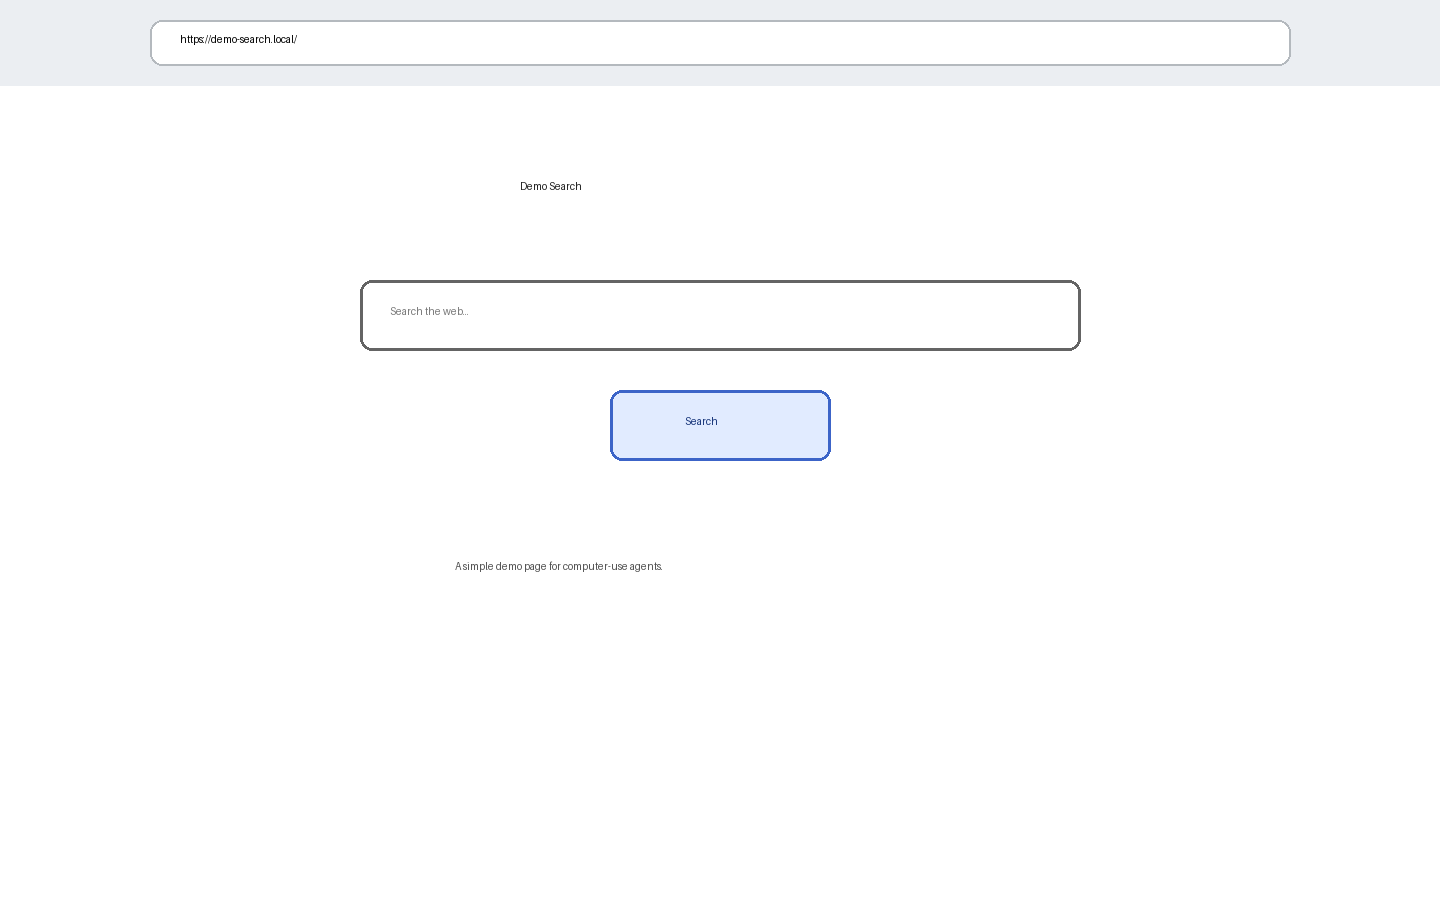

In [4]:
# =========================================
# コード4 動作確認用のブラウザ画面を作る
# =========================================
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

SAMPLE_DIR = Path("/content/fara15_samples")
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_SCREENSHOT = SAMPLE_DIR / "demo_browser_1440x900.png"

img = Image.new(
    "RGB",
    (1440, 900),
    "white",
)

draw = ImageDraw.Draw(img)

# browser chrome
draw.rectangle(
    [0, 0, 1439, 85],
    fill=(235, 238, 242),
)

draw.rounded_rectangle(
    [150, 20, 1290, 65],
    radius=12,
    fill="white",
    outline=(180, 185, 190),
    width=2,
)

draw.text(
    (180, 33),
    "https://demo-search.local/",
    fill="black",
)

# page
draw.text(
    (520, 180),
    "Demo Search",
    fill=(30, 30, 30),
)

draw.rounded_rectangle(
    [360, 280, 1080, 350],
    radius=12,
    fill="white",
    outline=(100, 100, 100),
    width=3,
)

draw.text(
    (390, 305),
    "Search the web...",
    fill=(120, 120, 120),
)

draw.rounded_rectangle(
    [610, 390, 830, 460],
    radius=12,
    fill=(225, 235, 255),
    outline=(60, 100, 200),
    width=3,
)

draw.text(
    (685, 415),
    "Search",
    fill=(20, 50, 120),
)

draw.text(
    (455, 560),
    "A simple demo page for computer-use agents.",
    fill=(80, 80, 80),
)

img.save(SAMPLE_SCREENSHOT)

print("sample screenshot:", SAMPLE_SCREENSHOT)
print("resolution:", img.size)
display(img)


In [5]:
# =========================================
# コード5 Fara1.5-4Bで次のブラウザ操作を予測
# =========================================
task = (
    "Search for 'explainable AI' using the search box on this page. "
    "Choose only the next action; do not execute anything."
)

answer = fara_generate(
    task=task,
    image_path=SAMPLE_SCREENSHOT,
    max_new_tokens=256,
)

print(answer)


<tool_call>{"name":"computer_use","arguments":{"action":"type","input":"explainable AI"}}</tool_call>


In [6]:
# =========================================
# コード6 Gradioを用いたFara1.5-4B UI
# =========================================
import gradio as gr
import torch

print("gradio:", gr.__version__)


def gr_fara(task, screenshot):
    task = (task or "").strip()

    if not screenshot:
        return "スクリーンショットをアップロードしてください。"

    try:
        return fara_generate(
            task=task,
            image_path=screenshot,
            max_new_tokens=256,
        )

    except torch.cuda.OutOfMemoryError:
        torch.cuda.empty_cache()

        return (
            "CUDA out of memory が発生しました。"
            "ランタイムを再起動するか、画像サイズを小さくしてください。"
        )

    except Exception as e:
        return f"{type(e).__name__}: {e}"


with gr.Blocks(title="Fara1.5-4B Computer Use Demo") as fara_demo:
    gr.Markdown(
        "## Fara1.5-4B Computer Use Demo\n"
        "ブラウザ画面のスクリーンショットとタスクを入力すると、"
        "次に行うべきブラウザ操作を予測します。\n\n"
        "**このNotebookは操作を自動実行しません。**"
    )

    screenshot_box = gr.Image(
        label="Browser Screenshot",
        type="filepath",
    )

    task_box = gr.Textbox(
        label="Task",
        value="Search for 'explainable AI' using the search box on this page.",
        lines=3,
    )

    with gr.Row():
        send_btn = gr.Button(
            "Send",
            variant="primary",
        )
        clear_btn = gr.Button("Clear")

    output_box = gr.Textbox(
        label="Predicted next action",
        lines=8,
    )

    send_btn.click(
        fn=gr_fara,
        inputs=[
            task_box,
            screenshot_box,
        ],
        outputs=output_box,
        queue=False,
    )

    clear_btn.click(
        lambda: ("", None, ""),
        outputs=[
            task_box,
            screenshot_box,
            output_box,
        ],
        queue=False,
    )

print("WARNING: share=Trueで公開URLが作成されます。")

fara_demo.launch(
    share=True,
    inline=True,
    debug=False,
)


gradio: 6.20.0
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://89a712ea3a7f205cc1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
